## Libraries

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스


### 데이터 불러오기

In [3]:
import csv
file_path = './2025_서울시 부동산 실거래가 정보.csv' # 파일 경로
data = []

with open(file_path, 'r', encoding='cp949') as file: # 한글 깨짐 방지를 위해 encoding='cp949' 사용
    reader = csv.reader(file)
    header = next(reader) 
    for row in reader:
        data.append(row)


### 데이터 전처리

In [17]:
import pandas as pd

df = pd.DataFrame(data, columns=header) # DataFrame 생성

## 결측치 처리
df = df.dropna(how='all')  # 모든 값이 NaN인 행 제거
df = df.dropna(how='all', axis=1)  # 모든 값이 NaN인 열 제거

# '거래금액(만원)' 열의 쉼표 제거 및 숫자형으로 변환
columns_to_convert = ['접수연도', '본번', '부번', '물건금액(만원)', '층', '건축년도']
for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

# 자치구명을 문자열로 변환
df['자치구명'] = df['자치구명'].astype(str)

In [ ]:
# Data1
selected_columns = ['접수연도', '본번', '부번', '물건금액(만원)', '층', '건축년도', '자치구명']
df1 = df[selected_columns]

# Data2
selected_columns2 = ['자치구명', '물건금액(만원)', '층', '건물면적(㎡)', '토지면적(㎡)']
df2 = df[selected_columns2]

In [18]:
print('----------------info------------------')
print(df1.info())
print('----------------Describe------------------')
print(df1.describe())
print('----------------Head------------------')
print(df1.head())

----------------info------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100787 entries, 0 to 100786
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   접수연도      100787 non-null  Int64 
 1   본번        97779 non-null   Int64 
 2   부번        97779 non-null   Int64 
 3   물건금액(만원)  100787 non-null  Int64 
 4   층         97779 non-null   Int64 
 5   건축년도      100449 non-null  Int64 
 6   자치구명      100787 non-null  object
dtypes: Int64(6), object(1)
memory usage: 6.0+ MB
None
----------------Describe------------------
           접수연도          본번         부번      물건금액(만원)         층         건축년도
count  100787.0     97779.0    97779.0      100787.0   97779.0     100449.0
mean     2025.0  547.022489  19.317318  98294.312391  7.992289  1984.007168
std         0.0  579.490581  95.436453  96004.676557  6.337726   203.020781
min      2025.0         1.0        0.0        2000.0      -2.0          0.0
25%      2025.0       

In [19]:
print('----------------info------------------')
print(df2.info())
print('----------------Describe------------------')
print(df2.describe())
print('----------------Head------------------')
print(df2.head())

----------------info------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100787 entries, 0 to 100786
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   자치구명      100787 non-null  object
 1   물건금액(만원)  100787 non-null  Int64 
 2   층         97779 non-null   Int64 
 3   건물면적(㎡)   100787 non-null  object
 4   토지면적(㎡)   100787 non-null  object
dtypes: Int64(2), object(3)
memory usage: 4.0+ MB
None
----------------Describe------------------
           물건금액(만원)         층
count      100787.0   97779.0
mean   98294.312391  7.992289
std    96004.676557  6.337726
min          2000.0      -2.0
25%         35750.0       3.0
50%         73700.0       6.0
75%        128101.5      12.0
max       3200000.0      67.0
----------------Head------------------
  자치구명  물건금액(만원)   층 건물면적(㎡) 토지면적(㎡)
0  광진구     46000   4   54.07      29
1  관악구     21000   3   29.43      18
2  관악구     19500  -1   59.22      31
3  관악구     55500   7   

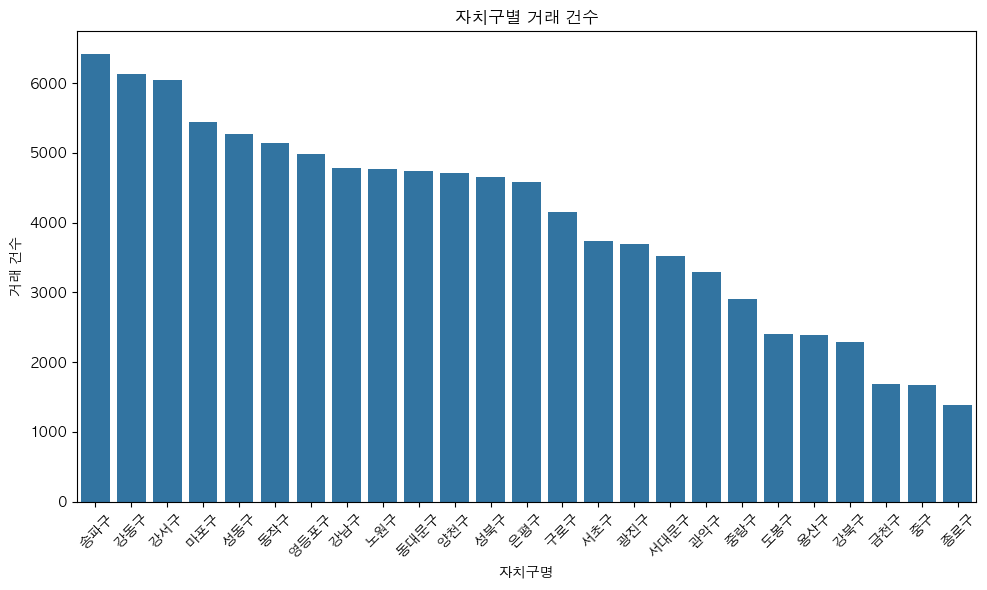

In [20]:
## 자치구별 거래 건수
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.countplot(data=df1, x='자치구명', order=df1['자치구명'].value_counts().index)
plt.title('자치구별 거래 건수') 
plt.xlabel('자치구명')
plt.ylabel('거래 건수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


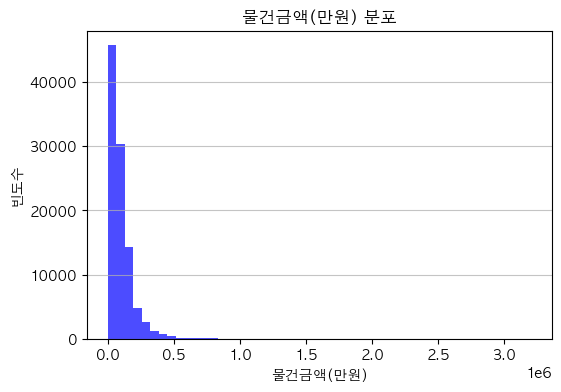

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(df['물건금액(만원)'].dropna(), bins=50, color='blue', alpha=0.7)
plt.title('물건금액(만원) 분포')
plt.xlabel('물건금액(만원)')
plt.ylabel('빈도수')
plt.grid(axis='y', alpha=0.75)